# **Nama : Arya Ferdiansyah Putra**

# **Kelas : Robotika Pagi C**

# **NIM : 4222301074**

# **Feature Engineering**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split

# Scalling untuk MinMax Scaller
from sklearn.preprocessing import MinMaxScaler
# Set the maximum number of columns and rows to display to a large number
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [2]:
df = pd.read_csv('dataset_kecelakaan.csv')

In [3]:
len(df)

300

In [4]:
len(df) - len(df.drop_duplicates())

0

In [5]:
len(df.drop_duplicates())

300

In [6]:
len(df.drop_duplicates()) / len(df)

1.0

In [7]:
duplicates = df[df.duplicated(keep=False)]

print("Baris dengan duplikat: ")
duplicates

Baris dengan duplikat: 


,ID,Usia,Jam_Kerja_per_Minggu,Pengalaman_Tahun,Pelatihan_K3,Shift,Jabatan,Lokasi,Kecelakaan


In [8]:
df = df.drop_duplicates()

In [9]:
len(df) - len(df.drop_duplicates())

0

In [10]:
len(df.drop_duplicates()) / len(df)

1.0

## Outlier Handling : InterQuartile Handling

In [11]:
import pandas as pd
import scipy.stats as stats

In [12]:
df_california = pd.read_csv('dataset_kecelakaan.csv')
df_california.head()

,ID,Usia,Jam_Kerja_per_Minggu,Pengalaman_Tahun,Pelatihan_K3,Shift,Jabatan,Lokasi,Kecelakaan
0,1,58,47,10,Ya,Pagi,Supervisor,Gudang,0
1,2,48,44,17,Tidak,Siang,Supervisor,Gudang,0
2,3,34,40,22,Ya,Pagi,Manager,Gudang,0
3,4,27,37,26,Tidak,Malam,Manager,Gudang,0
4,5,40,42,25,Tidak,Pagi,Supervisor,Gudang,0


In [13]:
from sklearn.model_selection import train_test_split
train_clfr, test_clfr = train_test_split(df_california, test_size = 0.2, random_state=42)

In [14]:
df_california.columns

Index(['ID', 'Usia', 'Jam_Kerja_per_Minggu', 'Pengalaman_Tahun',
       'Pelatihan_K3', 'Shift', 'Jabatan', 'Lokasi', 'Kecelakaan'],
      dtype='str')

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
def check_plot(df, variable):
    # fungsi mengambil kerangka data (df) dan
    # variabel yang diminati sebagai argumen

    # tentukan ukuran gambar
    plt.figure(figsize=(16, 4))

    # histogram
    plt.subplot(1, 3, 1)
    sns.histplot(df[variable], bins=30)
    plt.title('Histogram')

    # plot Q-Q
    plt.subplot(1, 3, 2)
    stats.probplot(df[variable], dist="norm", plot=plt)
    plt.ylabel('Variable quantiles')

    # box plot
    plt.subplot(1, 3, 3)
    sns.boxplot(y=df[variable])
    plt.title('Boxplot')

    plt.show()

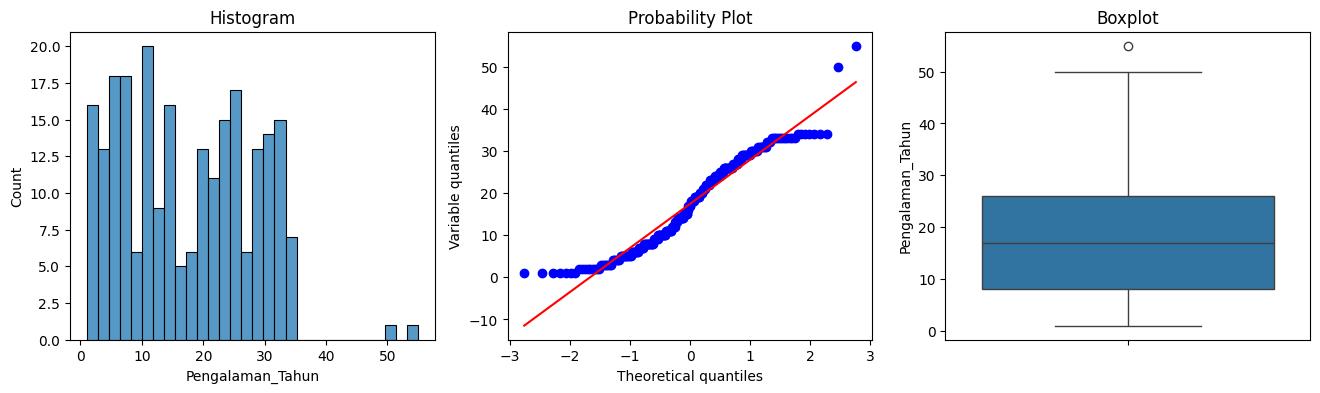

In [16]:
check_plot(train_clfr, 'Pengalaman_Tahun')

In [17]:
def find_outlier_boundary(df, variable):

    # Mari kita hitung batas luar yang merupakan outlier

    IQR = df[variable].quantile(0.75) - df[variable].quantile(0.25)

    lower_boundary = df[variable].quantile(0.25) - (IQR * 1.5)
    upper_boundary = df[variable].quantile(0.75) + (IQR * 1.5)

    return upper_boundary, lower_boundary

In [18]:
Population_upper_limit, Population_lower_limit = find_outlier_boundary(train_clfr, 'Pengalaman_Tahun')
Population_upper_limit, Population_lower_limit

(np.float64(53.0), np.float64(-19.0))



*   Upper Limit (3131.5) → Nilai di atas ini dianggap sebagai outlier.
*   Lower Limit (-616.5) → Nilai di bawah ini juga dianggap sebagai outlier.



In [19]:
import numpy as np

In [20]:
# Sekarang mari kita ganti outlier dengan batas maksimum dan minimum

train_clfr['Pengalaman_Tahun'] = np.where(
    train_clfr['Pengalaman_Tahun'] > Population_upper_limit, Population_upper_limit,  # Jika lebih besar dari batas atas, ganti dengan batas atas
    np.where(
        train_clfr['Pengalaman_Tahun'] < Population_lower_limit, Population_lower_limit,  # Jika lebih kecil dari batas bawah, ganti dengan batas bawah
        train_clfr['Pengalaman_Tahun']  # Jika tidak outlier, biarkan tetap sama
    )
)

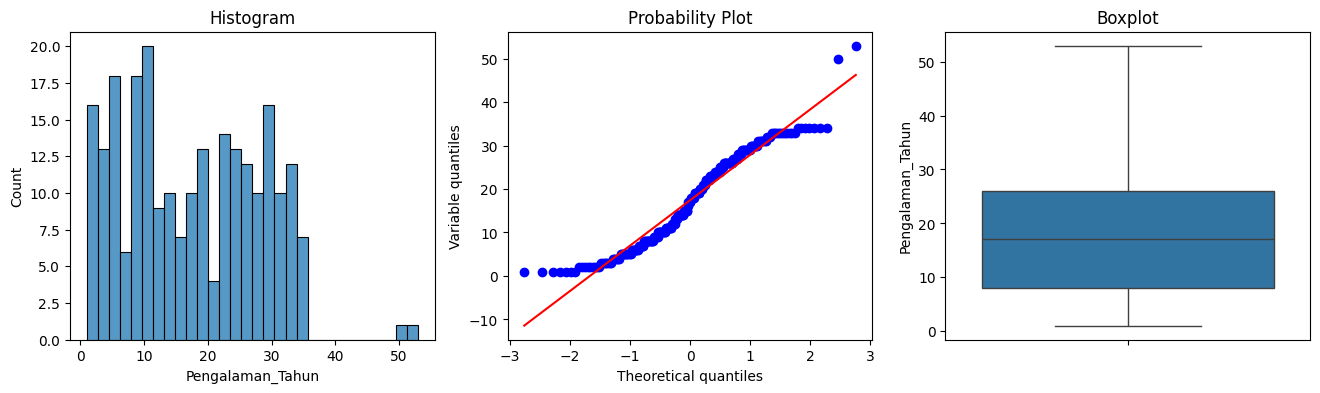

In [21]:
check_plot(train_clfr, 'Pengalaman_Tahun')

## Outlier Handling : Nilai Sembarang (Business Perspective)

In [22]:
!pip install feature_engine

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com


In [23]:
from feature_engine.outliers import ArbitraryOutlierCapper

In [24]:
from sklearn.model_selection import train_test_split
train_titanic, test_titanic = train_test_split(df, test_size = 0.2, random_state=42)

In [25]:
df.columns

Index(['ID', 'Usia', 'Jam_Kerja_per_Minggu', 'Pengalaman_Tahun',
       'Pelatihan_K3', 'Shift', 'Jabatan', 'Lokasi', 'Kecelakaan'],
      dtype='str')

In [26]:
train_titanic.Usia.describe()

count    240.000000
mean      40.870833
std       12.000174
min       15.000000
25%       30.750000
50%       42.500000
75%       52.000000
max       70.000000
Name: Usia, dtype: float64

In [27]:
teknik_capper = ArbitraryOutlierCapper(max_capping_dict={'Usia': 80},
                                       min_capping_dict={'Usia': 3})

teknik_capper.fit(train_titanic.fillna(0))

,max_capping_dict,{'Usia': 80}
,min_capping_dict,{'Usia': 3}
,missing_values,'raise'


In [28]:
temp_titanic = teknik_capper.transform(train_titanic.fillna(0))

In [29]:
temp_titanic.Usia.describe()

count    240.000000
mean      40.870833
std       12.000174
min       15.000000
25%       30.750000
50%       42.500000
75%       52.000000
max       70.000000
Name: Usia, dtype: float64

# **Missing Value Handling**

In [30]:
df_Kecelakaan = pd.read_csv('dataset_kecelakaan.csv')

In [31]:
df_Kecelakaan.head()

,ID,Usia,Jam_Kerja_per_Minggu,Pengalaman_Tahun,Pelatihan_K3,Shift,Jabatan,Lokasi,Kecelakaan
0,1,58,47,10,Ya,Pagi,Supervisor,Gudang,0
1,2,48,44,17,Tidak,Siang,Supervisor,Gudang,0
2,3,34,40,22,Ya,Pagi,Manager,Gudang,0
3,4,27,37,26,Tidak,Malam,Manager,Gudang,0
4,5,40,42,25,Tidak,Pagi,Supervisor,Gudang,0


In [32]:
df_Kecelakaan.isna().sum()

ID                      0
Usia                    0
Jam_Kerja_per_Minggu    0
Pengalaman_Tahun        0
Pelatihan_K3            0
Shift                   0
Jabatan                 0
Lokasi                  0
Kecelakaan              0
dtype: int64

In [33]:
for column in df_Kecelakaan.columns:
    print(f"============= {column} =================")
    display(df_Kecelakaan[column].value_counts())
    print()

============= ID =================


ID
1      1
2      1
3      1
4      1
5      1
6      1
7      1
8      1
9      1
10     1
11     1
12     1
13     1
14     1
15     1
16     1
17     1
18     1
19     1
20     1
21     1
22     1
23     1
24     1
25     1
26     1
27     1
28     1
29     1
30     1
31     1
32     1
33     1
34     1
35     1
36     1
37     1
38     1
39     1
40     1
41     1
42     1
43     1
44     1
45     1
46     1
47     1
48     1
49     1
50     1
51     1
52     1
53     1
54     1
55     1
56     1
57     1
58     1
59     1
60     1
61     1
62     1
63     1
64     1
65     1
66     1
67     1
68     1
69     1
70     1
71     1
72     1
73     1
74     1
75     1
76     1
77     1
78     1
79     1
80     1
81     1
82     1
83     1
84     1
85     1
86     1
87     1
88     1
89     1
90     1
91     1
92     1
93     1
94     1
95     1
96     1
97     1
98     1
99     1
100    1
101    1
102    1
103    1
104    1
105    1
106    1
107    1
108    1
109    1
110    1
111    


============= Usia =================


Usia
52    14
43    13
54    13
58    11
47    11
27    10
21    10
51    10
22     9
56     9
48     8
34     8
44     8
26     8
28     8
45     8
20     8
30     7
55     7
59     7
41     7
49     7
46     7
35     7
23     7
39     7
25     7
40     6
38     6
42     6
37     6
33     6
36     6
57     5
31     5
24     5
53     4
32     3
50     2
65     1
29     1
70     1
15     1
Name: count, dtype: int64


============= Jam_Kerja_per_Minggu =================


Jam_Kerja_per_Minggu
45     28
42     24
48     23
44     21
46     21
47     20
41     20
40     18
49     17
43     17
50     12
39     11
37     10
38     10
51      8
55      7
52      6
36      5
53      5
34      4
54      3
35      2
64      1
80      1
56      1
28      1
100     1
10      1
33      1
60      1
Name: count, dtype: int64


============= Pengalaman_Tahun =================


Pengalaman_Tahun
33    15
26    13
8     12
6     12
29    12
10    11
30    11
11    11
2     11
20    10
4     10
5     10
1     10
14    10
23    10
22     8
25     8
3      8
19     8
31     8
24     8
7      8
18     7
34     7
9      7
28     7
32     7
17     6
13     6
21     6
15     6
12     6
27     6
16     2
50     1
60     1
55     1
Name: count, dtype: int64


============= Pelatihan_K3 =================


Pelatihan_K3
Ya       157
Tidak    143
Name: count, dtype: int64


============= Shift =================


Shift
Pagi     109
Siang     96
Malam     95
Name: count, dtype: int64


============= Jabatan =================


Jabatan
Supervisor    111
Operator       97
Manager        92
Name: count, dtype: int64


============= Lokasi =================


Lokasi
Gudang             105
Produksi           104
Quality_Control     91
Name: count, dtype: int64


============= Kecelakaan =================


Kecelakaan
0    216
1     84
Name: count, dtype: int64

In [34]:
100 * len(df_Kecelakaan[df_Kecelakaan['Jam_Kerja_per_Minggu']==-1]) / len(df_Kecelakaan) #untuk menghitung persentase data dengan nilai Rating = -1 dalam dataset

0.0

In [35]:
100 * len(df_Kecelakaan[df_Kecelakaan['Usia'].isin(['-1','Unknown'])]) / len(df_Kecelakaan) #Menghitung persentase data yang kolom Size-nya bernilai '-1' atau 'Unknown'

0.0

In [36]:
100 * len(df_Kecelakaan[df_Kecelakaan['ID'].isin(['-1','Unknown / Non-Applicable'])]) / len(df_Kecelakaan)

0.0

In [37]:
df_Kecelakaan = df_Kecelakaan.drop(columns=['ID'])
df_Kecelakaan.info()

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Usia                  300 non-null    int64
 1   Jam_Kerja_per_Minggu  300 non-null    int64
 2   Pengalaman_Tahun      300 non-null    int64
 3   Pelatihan_K3          300 non-null    str  
 4   Shift                 300 non-null    str  
 5   Jabatan               300 non-null    str  
 6   Lokasi                300 non-null    str  
 7   Kecelakaan            300 non-null    int64
dtypes: int64(4), str(4)
memory usage: 18.9 KB


In [38]:
from sklearn.model_selection import train_test_split
train_company, test_company = train_test_split(df_Kecelakaan, test_size = 0.2, random_state=42)

In [39]:
# Imputasi median pada kolom Rating : train

median_rating_train = train_company[train_company['Jam_Kerja_per_Minggu']!=-1]['Jam_Kerja_per_Minggu'].median()

In [40]:
median_rating_train

np.float64(44.5)

In [41]:
#menerapkan imputasi nilai yang hilang untuk melatih dan menguji, dari pemeringkatan nilai median dalam data train
train_company['Rating'] = train_company['Jam_Kerja_per_Minggu'].apply(lambda x: median_rating_train if x==-1 else x) #train
test_company['Rating'] = test_company['Jam_Kerja_per_Minggu'].apply(lambda x: median_rating_train if x==-1 else x) #test

In [42]:
train_company['Jam_Kerja_per_Minggu'].value_counts()

Jam_Kerja_per_Minggu
45     19
42     19
48     19
47     18
41     17
44     17
40     16
46     15
43     13
49     13
50     10
39     10
38      8
37      8
51      6
55      5
36      5
52      4
53      4
34      3
54      3
35      2
100     1
10      1
60      1
33      1
64      1
56      1
Name: count, dtype: int64

In [43]:
df_churn = pd.read_csv('dataset_kecelakaan.csv')
df_churn.head(6)

,ID,Usia,Jam_Kerja_per_Minggu,Pengalaman_Tahun,Pelatihan_K3,Shift,Jabatan,Lokasi,Kecelakaan
0,1,58,47,10,Ya,Pagi,Supervisor,Gudang,0
1,2,48,44,17,Tidak,Siang,Supervisor,Gudang,0
2,3,34,40,22,Ya,Pagi,Manager,Gudang,0
3,4,27,37,26,Tidak,Malam,Manager,Gudang,0
4,5,40,42,25,Tidak,Pagi,Supervisor,Gudang,0
5,6,58,49,17,Tidak,Siang,Manager,Gudang,0


In [44]:
# Mengganti "Yes" menjadi 1 dan "No" menjadi 0 dalam kolom "Churn"
df_churn['Kecelakaan'] = df_churn['Kecelakaan'].replace({'Yes': 1, 'No': 0})
df_churn.head()

,ID,Usia,Jam_Kerja_per_Minggu,Pengalaman_Tahun,Pelatihan_K3,Shift,Jabatan,Lokasi,Kecelakaan
0,1,58,47,10,Ya,Pagi,Supervisor,Gudang,0
1,2,48,44,17,Tidak,Siang,Supervisor,Gudang,0
2,3,34,40,22,Ya,Pagi,Manager,Gudang,0
3,4,27,37,26,Tidak,Malam,Manager,Gudang,0
4,5,40,42,25,Tidak,Pagi,Supervisor,Gudang,0


In [45]:
#Cek nilai-nilai di kolom kategorikal
custom_columns = ['Pelatihan_K3','Shift',
                  'Jabatan','Lokasi','Kecelakaan']
for column in custom_columns:
    print(f"============= {column} =================")
    display(df_churn[column].value_counts())
    print()

============= Pelatihan_K3 =================


Pelatihan_K3
Ya       157
Tidak    143
Name: count, dtype: int64


============= Shift =================


Shift
Pagi     109
Siang     96
Malam     95
Name: count, dtype: int64


============= Jabatan =================


Jabatan
Supervisor    111
Operator       97
Manager        92
Name: count, dtype: int64


============= Lokasi =================


Lokasi
Gudang             105
Produksi           104
Quality_Control     91
Name: count, dtype: int64


============= Kecelakaan =================


Kecelakaan
0    216
1     84
Name: count, dtype: int64

In [46]:
train_churn, test_churn = train_test_split(df_churn, test_size = 0.2, random_state = 42)

In [47]:
# Melakukan one-hot encoding pada kolom "gender"
# Kolom-kolom yang ingin di one-hot encoding
encode_ohe = ['Kecelakaan'] #buat list nama-nama kolom yang ingin dilakukan OHE
train_churn = pd.get_dummies(train_churn, columns=encode_ohe, dtype=int)
test_churn = pd.get_dummies(test_churn, columns=encode_ohe, dtype=int)

In [48]:
train_churn.head()

,ID,Usia,Jam_Kerja_per_Minggu,Pengalaman_Tahun,Pelatihan_K3,Shift,Jabatan,Lokasi,Kecelakaan_0,Kecelakaan_1
232,233,24,50,19,Tidak,Siang,Manager,Produksi,1,0
59,60,53,43,12,Tidak,Pagi,Supervisor,Gudang,1,0
6,7,38,46,13,Tidak,Siang,Operator,Gudang,1,0
185,186,25,47,1,Ya,Siang,Manager,Quality_Control,1,0
173,174,21,40,28,Tidak,Malam,Operator,Quality_Control,1,0


In [49]:
test_churn.head()

,ID,Usia,Jam_Kerja_per_Minggu,Pengalaman_Tahun,Pelatihan_K3,Shift,Jabatan,Lokasi,Kecelakaan_0,Kecelakaan_1
203,204,22,42,25,Ya,Pagi,Operator,Gudang,1,0
266,267,39,40,32,Tidak,Pagi,Supervisor,Produksi,0,1
152,153,46,47,31,Ya,Siang,Supervisor,Produksi,1,0
9,10,30,46,4,Tidak,Siang,Supervisor,Quality_Control,1,0
233,234,56,45,18,Ya,Siang,Supervisor,Gudang,1,0


## **Label Encoder**

In [50]:
from sklearn.preprocessing import LabelEncoder

# Kolom-kolom yang ingin di-label encode
columns_to_encode = ['Pelatihan_K3']

# Inisialisasi LabelEncoder
label_encoder = LabelEncoder()

In [51]:
# Menerapkan label encoding ke data pelatihan (train)
for col in columns_to_encode:
    train_churn[col] = label_encoder.fit_transform(train_churn[col])
#fit dilakukan di data train dan implementasikan ke train, kemudian lakukan transform ke data test Untuk mencegah data leakage

In [52]:
train_churn.head()

,ID,Usia,Jam_Kerja_per_Minggu,Pengalaman_Tahun,Pelatihan_K3,Shift,Jabatan,Lokasi,Kecelakaan_0,Kecelakaan_1
232,233,24,50,19,0,Siang,Manager,Produksi,1,0
59,60,53,43,12,0,Pagi,Supervisor,Gudang,1,0
6,7,38,46,13,0,Siang,Operator,Gudang,1,0
185,186,25,47,1,1,Siang,Manager,Quality_Control,1,0
173,174,21,40,28,0,Malam,Operator,Quality_Control,1,0


In [53]:
test_churn.head()

,ID,Usia,Jam_Kerja_per_Minggu,Pengalaman_Tahun,Pelatihan_K3,Shift,Jabatan,Lokasi,Kecelakaan_0,Kecelakaan_1
203,204,22,42,25,Ya,Pagi,Operator,Gudang,1,0
266,267,39,40,32,Tidak,Pagi,Supervisor,Produksi,0,1
152,153,46,47,31,Ya,Siang,Supervisor,Produksi,1,0
9,10,30,46,4,Tidak,Siang,Supervisor,Quality_Control,1,0
233,234,56,45,18,Ya,Siang,Supervisor,Gudang,1,0


## **Feature Scalling**

## 1. StandarScaler

In [54]:
from sklearn.preprocessing import StandardScaler

# Kolom-kolom yang ingin di-standarisasi
columns_to_stdscaller = ['Jam_Kerja_per_Minggu', 'Pengalaman_Tahun']

# Inisialisasi StandardScaler
scaler = StandardScaler()

In [55]:
train_churn.info()

<class 'pandas.DataFrame'>
Index: 240 entries, 232 to 102
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   ID                    240 non-null    int64
 1   Usia                  240 non-null    int64
 2   Jam_Kerja_per_Minggu  240 non-null    int64
 3   Pengalaman_Tahun      240 non-null    int64
 4   Pelatihan_K3          240 non-null    int64
 5   Shift                 240 non-null    str  
 6   Jabatan               240 non-null    str  
 7   Lokasi                240 non-null    str  
 8   Kecelakaan_0          240 non-null    int64
 9   Kecelakaan_1          240 non-null    int64
dtypes: int64(7), str(3)
memory usage: 20.6 KB


In [56]:
# Menerapkan standarisasi ke data pelatihan (train)
# Convert 'Jam_Kerja_per_Minggu' and 'Pengalaman_Tahun' to numeric if they are datetime objects
train_churn['Jam_Kerja_per_Minggu'] = pd.to_numeric(train_churn['Jam_Kerja_per_Minggu'], errors='coerce')
train_churn['Pengalaman_Tahun'] = pd.to_numeric(train_churn['Pengalaman_Tahun'], errors='coerce')
train_churn[['Jam_Kerja_per_Minggu_stds', 'Pengalaman_Tahun_stds']] = scaler.fit_transform(train_churn[columns_to_stdscaller])

# Menerapkan standarisasi yang sama ke data uji (test)
# Convert 'Jam_Kerja_per_Minggu' and 'Pengalaman_Tahun' to numeric if they are datetime objects
test_churn['Jam_Kerja_per_Minggu'] = pd.to_numeric(test_churn['Jam_Kerja_per_Minggu'], errors='coerce')
test_churn['Pengalaman_Tahun'] = pd.to_numeric(test_churn['Pengalaman_Tahun'], errors='coerce')
test_churn[['Jam_Kerja_per_Minggu_stds', 'Pengalaman_Tahun_stds']] = scaler.transform(test_churn[columns_to_stdscaller])

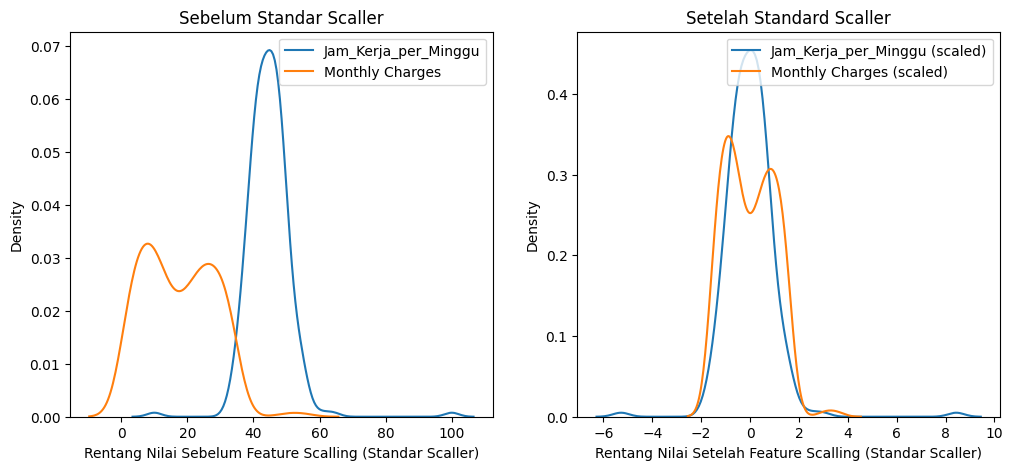

In [57]:
# kita lihat distribusi dari variabel sebelum standar scaller dan setelah standar scaller

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# Plot distribusi sebelum Standar Scaler
ax1.set_title('Sebelum Standar Scaller')
sns.kdeplot(train_churn['Jam_Kerja_per_Minggu'], ax=ax1, label='Jam_Kerja_per_Minggu')
sns.kdeplot(train_churn['Pengalaman_Tahun'], ax=ax1, label='Monthly Charges')

# Plot distribusi setelah Standar Scaler
ax2.set_title('Setelah Standard Scaller')
sns.kdeplot(train_churn['Jam_Kerja_per_Minggu_stds'], ax=ax2, label='Jam_Kerja_per_Minggu (scaled)')
sns.kdeplot(train_churn['Pengalaman_Tahun_stds'], ax=ax2, label='Monthly Charges (scaled)')

# Set x-labels
ax1.set_xlabel('Rentang Nilai Sebelum Feature Scalling (Standar Scaller)')
ax2.set_xlabel('Rentang Nilai Setelah Feature Scalling (Standar Scaller)')

# Menampilkan legenda
ax1.legend()
ax2.legend()

plt.show()

## 2.MinMaxScaler

In [58]:
from sklearn.preprocessing import MinMaxScaler

# Kolom-kolom yang ingin dinormalisasi
columns_to_normalize = ['Jam_Kerja_per_Minggu', 'Pengalaman_Tahun']

# Inisialisasi MinMaxScaler
minmax = MinMaxScaler()

In [59]:
# Menerapkan normalisasi Min-Max ke data pelatihan (train)
train_churn[['Jam_Kerja_per_Minggu_minmax', 'Pengalaman_Tahun_minmax']] = minmax.fit_transform(train_churn[columns_to_normalize])

# Menerapkan normalisasi Min-Max yang sama ke data uji (test)
test_churn[['Jam_Kerja_per_Minggu_minmax', 'Pengalaman_Tahun_minmax']] = minmax.transform(test_churn[columns_to_normalize])

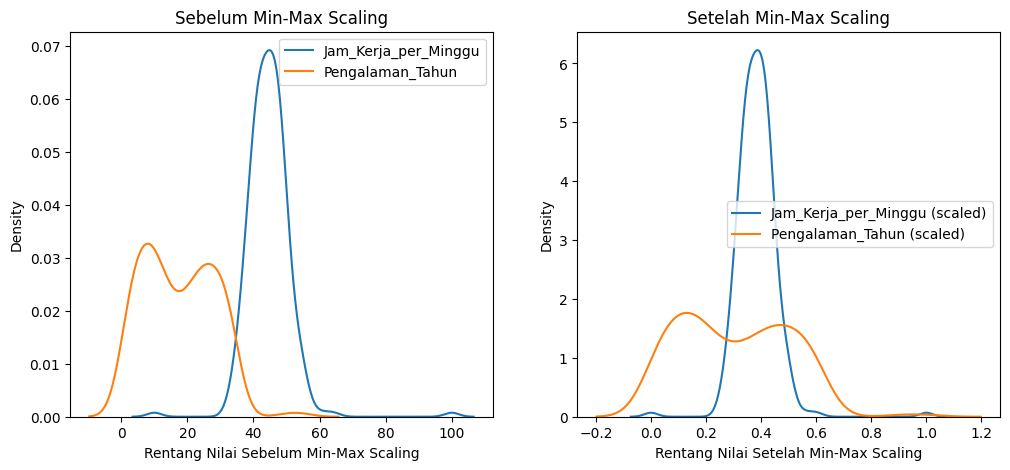

In [60]:
# Plot distribusi sebelum dan sesudah Min-Max Scaling
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# Plot distribusi sebelum Min-Max Scaling
ax1.set_title('Sebelum Min-Max Scaling')
sns.kdeplot(train_churn['Jam_Kerja_per_Minggu'], ax=ax1, label='Jam_Kerja_per_Minggu')
sns.kdeplot(train_churn['Pengalaman_Tahun'], ax=ax1, label='Pengalaman_Tahun')

# Plot distribusi setelah Min-Max Scaling
ax2.set_title('Setelah Min-Max Scaling')
sns.kdeplot(train_churn['Jam_Kerja_per_Minggu_minmax'], ax=ax2, label='Jam_Kerja_per_Minggu (scaled)')
sns.kdeplot(train_churn['Pengalaman_Tahun_minmax'], ax=ax2, label='Pengalaman_Tahun (scaled)')

# Set x-labels
ax1.set_xlabel('Rentang Nilai Sebelum Min-Max Scaling')
ax2.set_xlabel('Rentang Nilai Setelah Min-Max Scaling')

# Menampilkan legenda
ax1.legend()
ax2.legend()

plt.show()

In [61]:
train_churn[['Jam_Kerja_per_Minggu_minmax','Pengalaman_Tahun_minmax']].describe()

,Jam_Kerja_per_Minggu_minmax,Pengalaman_Tahun_minmax
count,240.000000,240.000000
mean,0.384722,0.304012
std,0.073077,0.197514
min,0.000000,0.000000
25%,0.344444,0.129630
50%,0.383333,0.296296
75%,0.422222,0.462963
max,1.000000,1.000000


# Supervised Learning

## Classification

### Preparation

Untuk persiapan, kita akan memanggil seluruh library yang akan kita pakai pada project kali ini

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
%matplotlib inline

In [63]:
train = pd.read_csv('dataset_kecelakaan.csv')
train.head()

,ID,Usia,Jam_Kerja_per_Minggu,Pengalaman_Tahun,Pelatihan_K3,Shift,Jabatan,Lokasi,Kecelakaan
0,1,58,47,10,Ya,Pagi,Supervisor,Gudang,0
1,2,48,44,17,Tidak,Siang,Supervisor,Gudang,0
2,3,34,40,22,Ya,Pagi,Manager,Gudang,0
3,4,27,37,26,Tidak,Malam,Manager,Gudang,0
4,5,40,42,25,Tidak,Pagi,Supervisor,Gudang,0


### Exploratory Data Analysis

In [64]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   ID                    300 non-null    int64
 1   Usia                  300 non-null    int64
 2   Jam_Kerja_per_Minggu  300 non-null    int64
 3   Pengalaman_Tahun      300 non-null    int64
 4   Pelatihan_K3          300 non-null    str  
 5   Shift                 300 non-null    str  
 6   Jabatan               300 non-null    str  
 7   Lokasi                300 non-null    str  
 8   Kecelakaan            300 non-null    int64
dtypes: int64(5), str(4)
memory usage: 21.2 KB


In [65]:
d = train.describe()
d

,ID,Usia,Jam_Kerja_per_Minggu,Pengalaman_Tahun,Kecelakaan
count,300.000000,300.000000,300.000000,300.000000,300.000000
mean,150.500000,40.376667,44.780000,17.746667,0.280000
std,86.746758,12.115448,6.597729,10.926747,0.449749
min,1.000000,15.000000,10.000000,1.000000,0.000000
25%,75.750000,30.000000,41.000000,8.000000,0.000000
50%,150.500000,42.000000,45.000000,18.000000,0.000000
75%,225.250000,51.000000,48.000000,27.000000,1.000000
max,300.000000,70.000000,100.000000,60.000000,1.000000


/tmp/ipykernel_3373/1680546196.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Kecelakaan',data=train,palette='RdBu_r')


<Axes: xlabel='Kecelakaan', ylabel='count'>

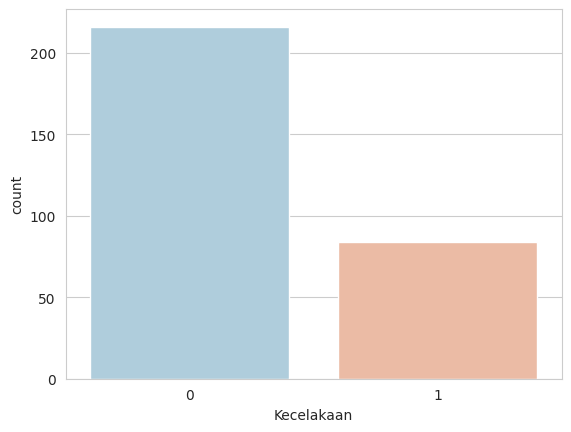

In [66]:
# Cek relative size dari survived dan not survived
sns.set_style('whitegrid')
sns.countplot(x='Kecelakaan',data=train,palette='RdBu_r')

<Axes: xlabel='Kecelakaan', ylabel='count'>

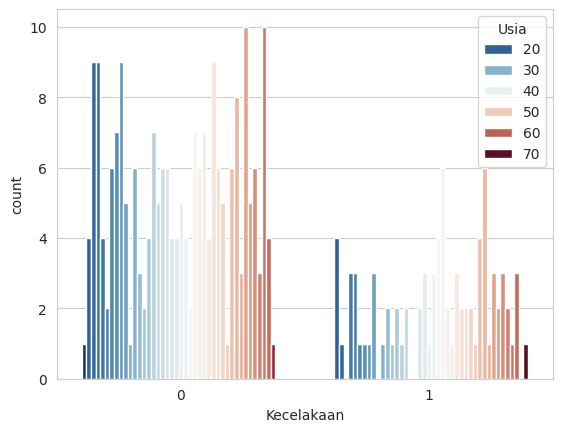

In [67]:
# Survivablity vs sex
sns.set_style('whitegrid')
sns.countplot(x='Kecelakaan',hue='Usia',data=train,palette='RdBu_r')

<Axes: xlabel='Kecelakaan', ylabel='count'>

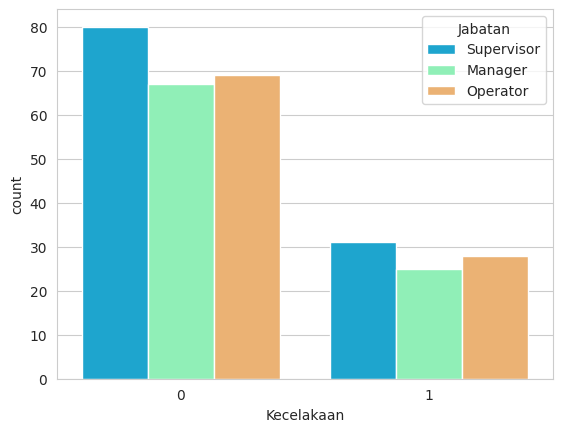

In [68]:
# Survivablity vs passenger class
sns.set_style('whitegrid')
sns.countplot(x='Kecelakaan',hue='Jabatan',data=train,palette='rainbow')

Text(0.5, 1.0, 'Persentase penumpang yang selamat berdasarkan kelas')

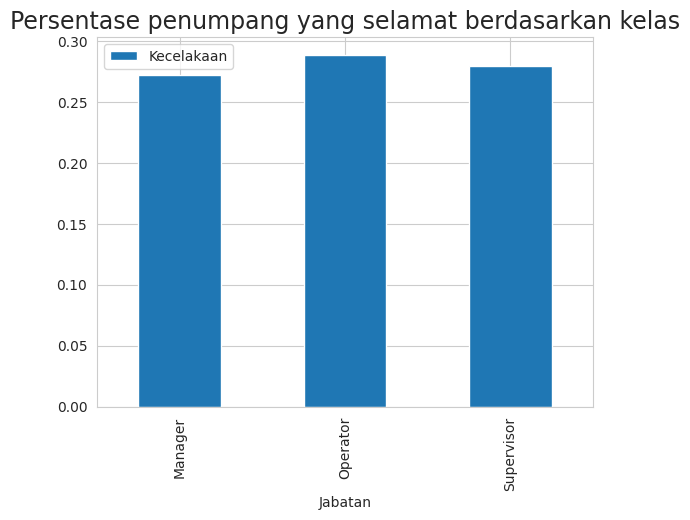

In [69]:
f_class_survived=train.groupby('Jabatan')['Kecelakaan'].mean()
f_class_survived = pd.DataFrame(f_class_survived)
f_class_survived
f_class_survived.plot.bar(y='Kecelakaan')
plt.title("Persentase penumpang yang selamat berdasarkan kelas",fontsize=17)

<Axes: xlabel='Kecelakaan', ylabel='count'>

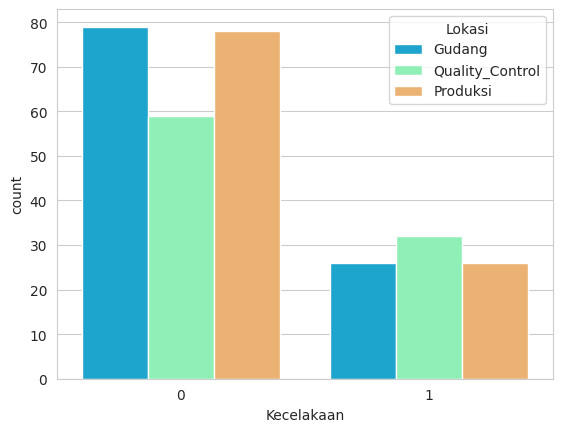

In [70]:
# Survived vs Sibling and Spouses
sns.set_style('whitegrid')
sns.countplot(x='Kecelakaan',hue='Lokasi',data=train,palette='rainbow')

<Axes: title={'center': 'Histogram usia pekerja'}, xlabel='Usia pekerja', ylabel='Count'>

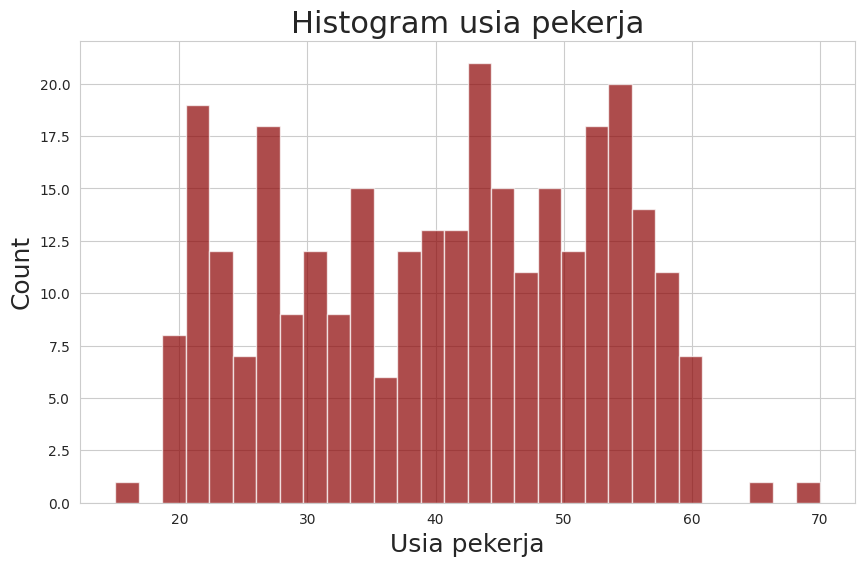

In [71]:
# Cek distribusi dari umur
plt.xlabel("Usia pekerja",fontsize=18)
plt.ylabel("Count",fontsize=18)
plt.title("Histogram usia pekerja",fontsize=22)
train['Usia'].hist(bins=30,color='darkred',alpha=0.7,figsize=(10,6))

/tmp/ipykernel_3373/1958863432.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Jabatan',y='Usia',data=train,palette='winter')


<Axes: xlabel='Jabatan', ylabel='Usia'>

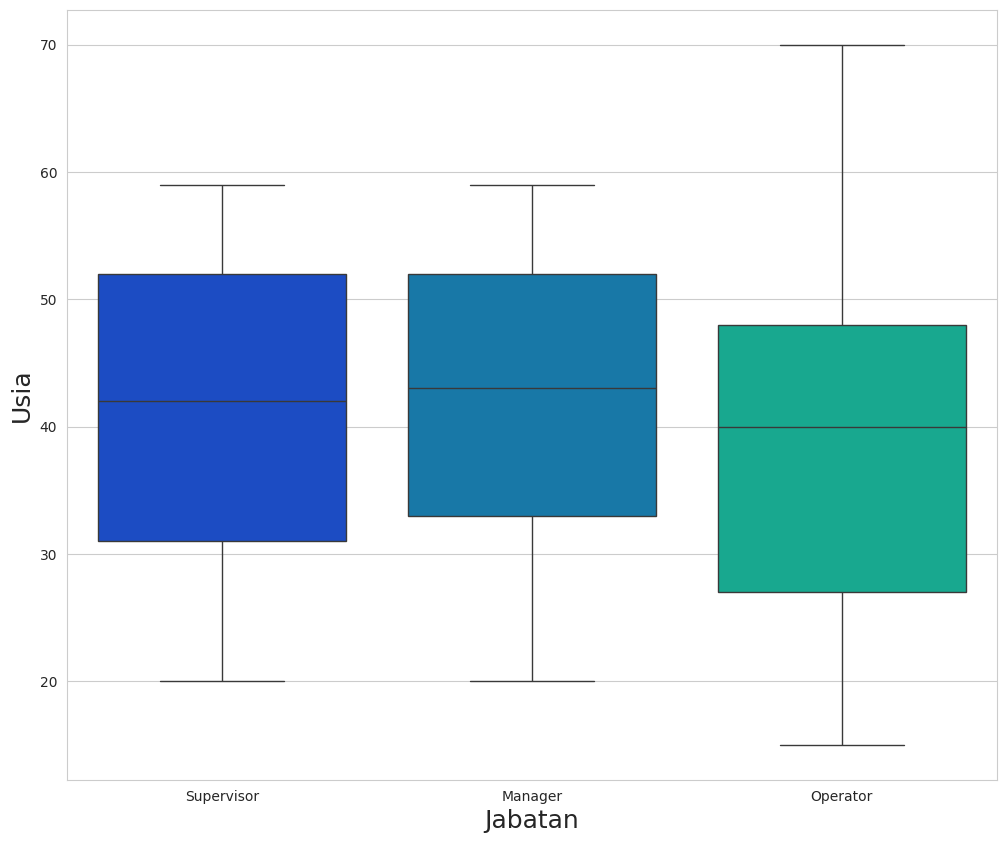

In [72]:
# Distribusi umur di setiap kelas
plt.figure(figsize=(12, 10))
plt.xlabel("Jabatan",fontsize=18)
plt.ylabel("Usia",fontsize=18)
sns.boxplot(x='Jabatan',y='Usia',data=train,palette='winter')

Text(0.5, 0, 'Jabatan')

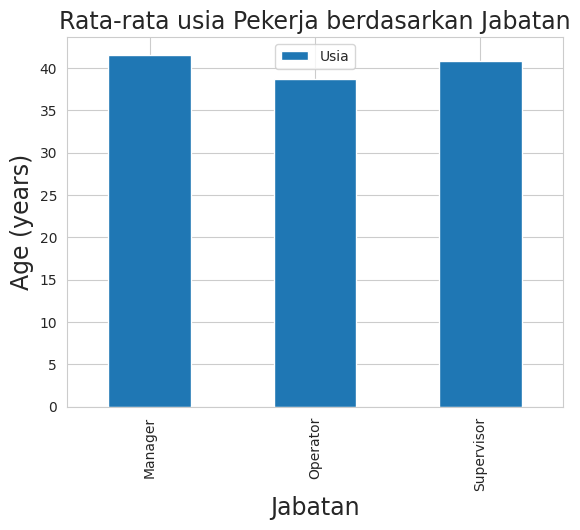

In [73]:
f_class_Age=train.groupby('Jabatan')['Usia'].mean()
f_class_Age = pd.DataFrame(f_class_Age)
f_class_Age.plot.bar(y='Usia')
plt.title("Rata-rata usia Pekerja berdasarkan Jabatan",fontsize=17)
plt.ylabel("Age (years)", fontsize=17)
plt.xlabel("Jabatan", fontsize=17)

### Fitur Engineering

In [74]:
a=list(f_class_Age['Usia'])

def impute_age(cols):
    Age = cols.iloc[0]
    Pclass = cols.iloc[1]

    if pd.isnull(Age):

        if Pclass == 1:
            return a[0]

        elif Pclass == 2:
            return a[1]

        else:
            return a[2]

    else:
        return Age

In [75]:
train['Usia'] = train[['Usia', 'Jabatan']].apply(impute_age, axis=1)

Text(0.5, 1.0, 'Bar plot jumlah fitur numerik')

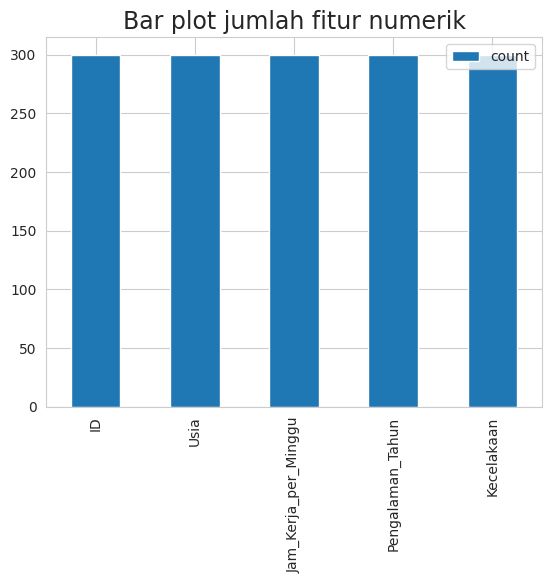

In [76]:
d=train.describe()
dT=d.T
dT.plot.bar(y='count')
plt.title("Bar plot jumlah fitur numerik",fontsize=17)

In [77]:
# drop cabin karena memiliki banyak null value (>50%)
train.drop('Shift',axis=1,inplace=True)
train.dropna(inplace=True)
train.head()

,ID,Usia,Jam_Kerja_per_Minggu,Pengalaman_Tahun,Pelatihan_K3,Jabatan,Lokasi,Kecelakaan
0,1,58,47,10,Ya,Supervisor,Gudang,0
1,2,48,44,17,Tidak,Supervisor,Gudang,0
2,3,34,40,22,Ya,Manager,Gudang,0
3,4,27,37,26,Tidak,Manager,Gudang,0
4,5,40,42,25,Tidak,Supervisor,Gudang,0


In [78]:
# Drop semua kolom yang tidak penting
train.drop(['ID','Usia','Jam_Kerja_per_Minggu'],axis=1,inplace=True)
train.head()

,Pengalaman_Tahun,Pelatihan_K3,Jabatan,Lokasi,Kecelakaan
0,10,Ya,Supervisor,Gudang,0
1,17,Tidak,Supervisor,Gudang,0
2,22,Ya,Manager,Gudang,0
3,26,Tidak,Manager,Gudang,0
4,25,Tidak,Supervisor,Gudang,0


In [79]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
train['Jabatan'] = le.fit_transform(train['Jabatan'])
train['Pelatihan_K3'] = le.fit_transform(train['Pelatihan_K3'])
train.head()

,Pengalaman_Tahun,Pelatihan_K3,Jabatan,Lokasi,Kecelakaan
0,10,1,2,Gudang,0
1,17,0,2,Gudang,0
2,22,1,0,Gudang,0
3,26,0,0,Gudang,0
4,25,0,2,Gudang,0


### Training

In [80]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(train.drop('Kecelakaan',axis=1),
                                                    train['Kecelakaan'], test_size=0.30,
                                                    random_state=42)

In [81]:
print(f'Train shape: {X_train.shape}')
print(f'Test shape: {X_test.shape}')

Train shape: (210, 4)
Test shape: (90, 4)


# **KNN**

In [82]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

cols = ['Pelatihan_K3', 'Shift', 'Jabatan', 'Lokasi']

for col in cols:
    if col in X_train.columns: 
        X_train[col] = le.fit_transform(X_train[col])
        X_test[col] = le.transform(X_test[col])

In [83]:
from sklearn.neighbors import KNeighborsClassifier

clf1 = KNeighborsClassifier()

clf1.fit(X_train, y_train)  # ⬅️ ini HARUS jalan tanpa error

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [84]:
y_pred = clf1.predict(X_test)

### Evaluation

In [85]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred) #akurasi model
print(f'Akurasi Model KNN: {accuracy:.2f}')

print("Confusion Matrix:") #confusion matrix nya
print(confusion_matrix(y_test, y_pred))

print("Classification Report:") #laporan klasifikasi
print(classification_report(y_test, y_pred))

Akurasi Model KNN: 0.67
Confusion Matrix:
[[57  6]
 [24  3]]
Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.90      0.79        63
           1       0.33      0.11      0.17        27

    accuracy                           0.67        90
   macro avg       0.52      0.51      0.48        90
weighted avg       0.59      0.67      0.60        90



### jika kita mau mengubah parameter apa saja yang akan kita gunakan maka bisa dilakukan seperti ini

In [86]:
clf2 = KNeighborsClassifier(n_neighbors=5, weights='distance', metric='euclidean')
clf2.fit(X_train, y_train)

y_pred1 = clf2.predict(X_test)

In [87]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred1) #akurasi model
print(f'Akurasi Model KNN: {accuracy:.2f}')

print("Confusion Matrix:") #confusion matrix nya
print(confusion_matrix(y_test, y_pred1))

print("Classification Report:") #laporan klasifikasi
print(classification_report(y_test, y_pred1))

Akurasi Model KNN: 0.66
Confusion Matrix:
[[54  9]
 [22  5]]
Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.86      0.78        63
           1       0.36      0.19      0.24        27

    accuracy                           0.66        90
   macro avg       0.53      0.52      0.51        90
weighted avg       0.60      0.66      0.62        90



### jika ingin mencoba semua parameter

In [88]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import pandas as pd

# 1. Definisikan metrik-metrik scoring yang ingin digunakan
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'precision': make_scorer(precision_score, average='macro'),
    'recall': make_scorer(recall_score, average='macro'),
    'f1': make_scorer(f1_score, average='macro')
}

# 2. Parameter grid
param_grid = {
    'n_neighbors': [3, 5, 7],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

# 3. Buat model KNN
knn = KNeighborsClassifier()

# 4. GridSearch dengan semua metrik, pilih 'f1' sebagai metrik utama (refit)
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring=scoring, refit='f1', verbose=1, n_jobs=-1)
grid_search.fit(X_train, y_train)

# 5. Hasil Cross-Validation (Training)
cv_results = pd.DataFrame(grid_search.cv_results_)
cv_metrics = cv_results[['params', 'mean_test_accuracy', 'mean_test_precision', 'mean_test_recall', 'mean_test_f1']]
print("\n=== Hasil Evaluasi Training (Cross-Validation) ===")
print(cv_metrics.sort_values(by='mean_test_f1', ascending=False))

Fitting 5 folds for each of 12 candidates, totalling 60 fits


/home/robot/miniconda3/envs/machine_learning/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])



=== Hasil Evaluasi Training (Cross-Validation) ===
                                               params  mean_test_accuracy  \
1   {'metric': 'euclidean', 'n_neighbors': 3, 'wei...            0.657143   
7   {'metric': 'manhattan', 'n_neighbors': 3, 'wei...            0.657143   
11  {'metric': 'manhattan', 'n_neighbors': 7, 'wei...            0.676190   
9   {'metric': 'manhattan', 'n_neighbors': 5, 'wei...            0.661905   
3   {'metric': 'euclidean', 'n_neighbors': 5, 'wei...            0.661905   
0   {'metric': 'euclidean', 'n_neighbors': 3, 'wei...            0.671429   
6   {'metric': 'manhattan', 'n_neighbors': 3, 'wei...            0.666667   
5   {'metric': 'euclidean', 'n_neighbors': 7, 'wei...            0.666667   
8   {'metric': 'manhattan', 'n_neighbors': 5, 'wei...            0.661905   
2   {'metric': 'euclidean', 'n_neighbors': 5, 'wei...            0.680952   
10  {'metric': 'manhattan', 'n_neighbors': 7, 'wei...            0.680952   
4   {'metric': 'euclidea

In [89]:
# Simpan hasil evaluasi ke file Excel
cv_metrics_sorted = cv_metrics.sort_values(by='mean_test_f1', ascending=False)
cv_metrics_sorted.to_excel("hasil_gridsearch_knn.xlsx", index=False)

print("Hasil telah disimpan ke 'hasil_gridsearch_knn.xlsx'")


Hasil telah disimpan ke 'hasil_gridsearch_knn.xlsx'


In [90]:
best_model = grid_search.best_estimator_
print("\n=== Parameter Terbaik ===")
print(grid_search.best_params_)


=== Parameter Terbaik ===
{'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'distance'}


In [91]:
y_pred = best_model.predict(X_test)
print("\n=== Evaluasi di Test Set ===")
print(f"Akurasi:  {accuracy_score(y_test, y_pred):.2f}")
print(f"Presisi:  {precision_score(y_test, y_pred, average='macro'):.2f}")
print(f"Recall:   {recall_score(y_test, y_pred, average='macro'):.2f}")
print(f"F1-Score: {f1_score(y_test, y_pred, average='macro'):.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


=== Evaluasi di Test Set ===
Akurasi:  0.71
Presisi:  0.64
Recall:   0.59
F1-Score: 0.60

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.89      0.81        63
           1       0.53      0.30      0.38        27

    accuracy                           0.71        90
   macro avg       0.64      0.59      0.60        90
weighted avg       0.68      0.71      0.68        90

Confusion Matrix:
[[56  7]
 [19  8]]


In [98]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier

# =========================
# LOAD DATA
# =========================
df = df_Kecelakaan.copy()

# =========================
# SPLIT FITUR & LABEL
# =========================
X = df.drop('Kecelakaan', axis=1)
y = df['Kecelakaan']

# =========================
# ENCODING (SIMPAN ENCODER)
# =========================
encoders = {}

for col in ['Pelatihan_K3', 'Shift', 'Jabatan', 'Lokasi']:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    encoders[col] = le

# =========================
# SPLIT DATA
# =========================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# =========================
# SCALING
# =========================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# =========================
# MODEL
# =========================
clf = KNeighborsClassifier()
clf.fit(X_train, y_train)

# =========================
# DATA BARU (AMAN)
# =========================
new_data = pd.DataFrame([{
    'Usia': 25,
    'Jam_Kerja_per_Minggu': 40,
    'Pengalaman_Tahun': 5,
    'Pelatihan_K3': 'Ya',
    'Shift': 'Pagi',
    'Jabatan': 'Operator',
    'Lokasi': 'Gudang'
}])

# encoding
for col in ['Pelatihan_K3', 'Shift', 'Jabatan', 'Lokasi']:
    new_data[col] = encoders[col].transform(new_data[col])

# scaling
new_data = scaler.transform(new_data)

# prediksi
prediction = clf.predict(new_data)

print("Prediksi (0 = Tidak Kecelakaan, 1 = Kecelakaan):", prediction[0])

Prediksi (0 = Tidak Kecelakaan, 1 = Kecelakaan): 0


### **2. Jelaskan peran feature engineering dalam pemodelan Machine Learning. Jelaskan contohnya dari studi kasus masing-masing. (20 Point, CLOP-4)**

#### **Apa itu Feature Engineering?**

Singkatnya, **feature engineering** itu adalah proses "merapikan" atau mengolah data mentah supaya model Machine Learning bisa lebih mudah membacanya.

Bayangkan data mentah itu seperti bahan makanan yang baru dibeli dari pasar (masih kotor, ada kulitnya, atau ukurannya kegedean). Nah, feature engineering adalah proses mengupas, memotong, dan membumbui bahan tersebut supaya pas dimasukkan ke "panci" algoritma. Kalau datanya sudah pas, modelnya bakal lebih pintar dan akurat dalam memberikan prediksi.

**Kenapa ini Penting?**

- **Bikin Model Lebih Akurat:** Kadang algoritma itu "bebal" kalau dikasih data mentah. Kita perlu menonjolkan pola yang penting supaya dia nggak bingung.

- **Hemat Waktu Komputasi:** Daripada model memproses banyak data yang nggak relevan, mending kita kasih satu atau dua variabel yang sudah jadi tapi sangat bermakna.

- **Mengubah yang Tak Mungkin Jadi Mungkin:** Mengubah data yang tadinya berbentuk tulisan, kategori, atau tanggal menjadi angka yang bisa dihitung secara matematis.

**Contoh**
- **Properti (Estimasi Harga):**

    - Data Mentah: Luas tanah dan luas bangunan.

    - Feature Engineering: **Luas Halaman** (Luas Tanah - Luas Bangunan).

    - Kenapa? Karena calon pembeli sering kali mempertimbangkan apakah ada sisa lahan untuk taman/parkir.

- **Perbankan (Deteksi Fraud):**

    - Data Mentah: Lokasi transaksi sekarang dan lokasi transaksi 10 menit lalu.

    - Feature Engineering: **Kecepatan Perpindahan** (Jarak antar lokasi / Selisih waktu).

    - Kenapa? Jika jaraknya 50km tapi hanya dalam 10 menit, model otomatis tahu itu mustahil dan pasti penipuan.

- **E-Commerce (Loyalitas Pelanggan):**

    - Data Mentah: Tanggal pertama kali daftar dan tanggal hari ini.

    - Feature Engineering: **Masa Keanggotaan** (Selisih hari dari daftar sampai sekarang).

    - Kenapa? Angka "500 hari jadi member" lebih berarti buat model daripada sekadar tanggal acak.

- **Sosial Media (Analisis Sentimen):**

    - Data Mentah: Teks komentar netizen.

    - Feature Engineering: **Jumlah Emoji Marah.**

    - Kenapa? Model lebih cepat mengenali emosi negatif lewat simbol daripada harus membedah arti tiap kata yang ribet.

### **3. Apa itu confusion metrik dan metrik evaluasi jika dilihat dari studi kasus masing-masing, Jelaskan? (20 Point, CLO-4)**